In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import pickle, h5py, os, glob
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# inference
from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.gaussian_likelihood.dense_emulator import DenseEmulator

# utils
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files

In [53]:
params = ["Om", "s8", "Aia"]
label = f"virginia_cls"

grid_dir = "/global/cfs/cdirs/des/vajani/combined-probes/output/Weak_Lensing/grid/Power_Spectra/dictionaries"
fidu_dir = "/global/cfs/cdirs/des/vajani/combined-probes/output/Weak_Lensing/fiducial/noisy/Power_spectra"

conf = files.load_config()
l_mins = conf["analysis"]["scale_cuts"]["lensing"]["l_min"]
l_maxs = conf["analysis"]["scale_cuts"]["lensing"]["l_max"]

# lensing only

## load the grid from Virginia's files

### fiducial

In [54]:
fidu_index = []
fidu_cls = []

for i in range(4):
    for j in range(4):
        if i <= j:
            bin_num = f"{i+1}x{j+1}"
            print(f"Loading bin_num = {bin_num}")

            # load ells
            centers = np.load(f'/global/cfs/cdirs/des/vajani/Cori/DESY3/SUMMARY/CENTERS_mode=E_stat=CrossCLs_tomo={bin_num}.npy').reshape(32)
            
            # scale cuts
            l_min = l_mins[i]
            l_max = l_maxs[i]
            l_cut = (l_min < centers) & (centers < l_max)
            n_summary = np.count_nonzero(l_cut)
            print(f"Using scale cuts l_min = {l_min}, l_max = {l_max}, which results in Cls of size {n_summary}")

            # load cls from .h5
            fidu_file_list = glob.glob(fidu_dir + "/bin1x1/WL_index_*_DESy3_fiducial_???.tfrecord.h5")
            print(f"found {len(fidu_file_list)} .h5 files")

            current_index = []
            current_cls = []

            for fidu_file in fidu_file_list:
                with h5py.File(fidu_file, "r") as f:
                    current_index.append(f["power_spectrum"].attrs["index"][0,0])
                    current_cls.append(f["power_spectrum"][:])
                    
            current_index = np.asarray(current_index)
            current_cls = np.asarray(current_cls)
            
            # every example index must be unique
            assert len(np.unique(current_index) == len(fidu_file_list))

            # sort
            i_sorted = np.argsort(current_index)
            current_index = current_index[i_sorted]
            current_cls = current_cls[i_sorted]
            
            # apply scale cut
            current_cls = current_cls[:,l_cut]
            
            # collect in lists
            fidu_index.append(current_index)
            fidu_cls.append(current_cls)

# collect the different cosmologies
fidu_index = np.stack(fidu_index, axis=-1, dtype=np.float32)
fidu_cls = np.concatenate(fidu_cls, axis=-1, dtype=np.float32)

print(f"\nfidu_index.shape = {fidu_index.shape}")
print(f"fidu_cls.shape = {fidu_cls.shape}")

Loading bin_num = 1x1
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
found 750 .h5 files
Loading bin_num = 1x2
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
found 750 .h5 files
Loading bin_num = 1x3
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
found 750 .h5 files
Loading bin_num = 1x4
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
found 750 .h5 files
Loading bin_num = 2x2
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
found 750 .h5 files
Loading bin_num = 2x3
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
found 750 .h5 files
Loading bin_num = 2x4
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
found 750 .h5 files
Loading bin_num = 3x3
Using scale cuts l_min = 30, l_max = 1408, which results in Cls of size 24
found 750 .h5 files
Loading bin_num = 3x4
Using scale cuts l_min = 30, l_max = 1408, whi

### grid

In [40]:
n_params = 3
n_examples = 16
n_summary = 32

# Om, s8, Aia
grid_theta = []
grid_cls = []

n_summaries = []

for i in range(4):
    for j in range(4):
        if i <= j:
            bin_num = f"{i+1}x{j+1}"
            print(f"Loading bin_num = {bin_num}")
                        
            # load grid cls
            with open(os.path.join(grid_dir, f'bin{bin_num}/power_spec_dict_bin{bin_num}.pickle'), 'rb') as f:
                current_dict = pickle.load(f)
            
            # load ells
            centers = np.load(f'/global/cfs/cdirs/des/vajani/Cori/DESY3/SUMMARY/CENTERS_mode=E_stat=CrossCLs_tomo={bin_num}.npy').reshape(32)
            
            # scale cuts
            l_min = l_mins[i]
            l_max = l_maxs[i]
            l_cut = (l_min < centers) & (centers < l_max)
            n_summary = np.count_nonzero(l_cut)
            print(f"Using scale cuts l_min = {l_min}, l_max = {l_max}, which results in Cls of size {n_summary}")
            n_summaries.append(n_summary)
            
            # container
            current_cls = np.zeros((len(current_dict), n_examples, n_summary))

            # loop through the dictionary
            for k, (key, value) in enumerate(current_dict.items()):
                # value is a list of length n_examples that contains arrays of shape (32,)
                Cls = np.asarray(value)[:,l_cut]
                # Cls = np.asarray(value)

                # extract the cosmological parameters
                current_theta_list = key.replace("[", "").replace("]", "").strip().split(" ")
                current_theta_list = list(filter(None, current_theta_list))
                current_theta_list = [float(item) for item in current_theta_list] 

                # only save the cosmological parameters once
                if i == 0 and j == 0:
                    grid_theta.append(np.array(current_theta_list))
                    
                # check otherwise
                else:
                    assert np.all(grid_theta[k] == current_theta_list)
                    
                current_cls[k] = np.stack(Cls, axis=0)
                
            grid_cls.append(current_cls)

# collect the different cosmologies
grid_theta = np.stack(grid_theta, axis=0, dtype=np.float32)
grid_cls = np.concatenate(grid_cls, axis=-1, dtype=np.float32)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

# remove the example axis
grid_cls = np.concatenate(grid_cls, axis=0, dtype=np.float32)
grid_theta = np.repeat(grid_theta, grid_cls.shape[0]//grid_theta.shape[0], axis=0)

print(f"\ngrid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

Loading bin_num = 1x1
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
Loading bin_num = 1x2
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
Loading bin_num = 1x3
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
Loading bin_num = 1x4
Using scale cuts l_min = 30, l_max = 723, which results in Cls of size 16
Loading bin_num = 2x2
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
Loading bin_num = 2x3
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
Loading bin_num = 2x4
Using scale cuts l_min = 30, l_max = 1054, which results in Cls of size 20
Loading bin_num = 3x3
Using scale cuts l_min = 30, l_max = 1408, which results in Cls of size 24
Loading bin_num = 3x4
Using scale cuts l_min = 30, l_max = 1408, which results in Cls of size 24
Loading bin_num = 4x4
Using scale cuts l_min = 30, l_max = 1535, which results in Cls of size 25

grid_theta.shape = (2499, 3)
grid

In [41]:
assert grid_cls.shape[1] == fidu_cls.shape[1]

### plot power spectra

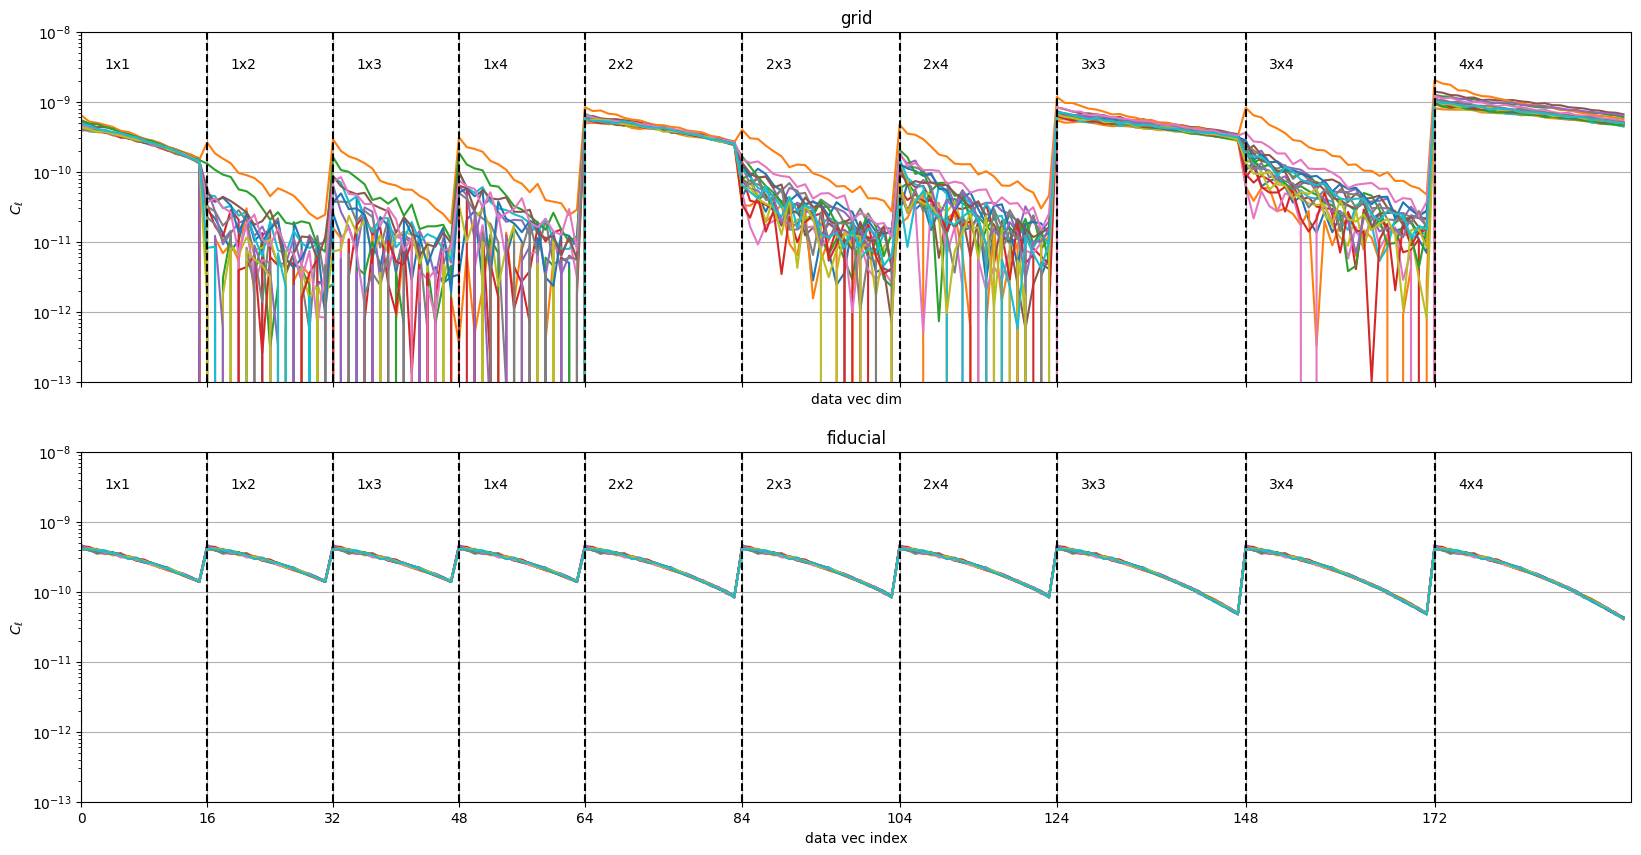

In [42]:
# grid
random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

fig, ax = plt.subplots(figsize=(20,10), nrows=2, sharex=True, sharey=True)

for i in random_indices:    
    ax[0].plot(grid_cls[i])
        
ax[0].set(xscale="linear", yscale="log", title=r"grid", xlim=(1, grid_cls.shape[1]), ylim=(1e-13, 1e-8), xlabel="data vec dim", ylabel=r"$C_\ell$")
ax[0].grid(True)

# fiducial
random_indices = np.random.choice(np.arange(fidu_cls.shape[0]), 20)

for i in random_indices:    
    ax[1].plot(fidu_cls[i])

ax[1].set(title=r"fiducial", xlabel="data vec index", ylabel=r"$C_\ell$")
ax[1].grid(True)

# cosmetics
x = 0
labels = ["1x1", "1x2", "1x3", "1x4", "2x2", "2x3", "2x4", "3x3", "3x4", "4x4"]
ticks = []
for i, n in enumerate(n_summaries):
    ax[0].axvline(x, color="k", linestyle="--")
    ax[1].axvline(x, color="k", linestyle="--")
    
    ax[0].text(x + 3, 3e-9, labels[i])
    ax[1].text(x + 3, 3e-9, labels[i])
    
    ticks.append(x)
    x += n
    
ax[0].set_xticks(ticks)
ax[1].set_xticks(ticks);

### observation

In [34]:
obs_cls = np.mean(fidu_cls, axis=0, keepdims=True)
# obs_cls = fidu_cls[0][np.newaxis]
# obs_cls = grid_cls[7][np.newaxis]

print(obs_cls.shape)

(1, 197)


### preprocessing

In [35]:
# PCA
pca = PCA(n_components=10)

grid_compressed_cls = pca.fit_transform(grid_cls)
fidu_compressed_cls = pca.transform(fidu_cls)
obs_compressed_cls = pca.transform(obs_cls)

print(f"grid shape before compression: {grid_cls.shape}")
print(f"grid shape after compression: {grid_compressed_cls.shape}")

# StandardScaler
scaler = StandardScaler()

grid_compressed_cls = scaler.fit_transform(grid_compressed_cls)
fidu_compressed_cls = scaler.transform(fidu_compressed_cls)
obs_compressed_cls = scaler.transform(obs_compressed_cls)

scaler = StandardScaler()

grid_standard_cls = scaler.fit_transform(grid_cls)
fidu_standard_cls = scaler.transform(fidu_cls)
obs_standard_cls = scaler.transform(obs_cls)

# fix dtype
grid_compressed_cls = grid_compressed_cls.astype(np.float32)
fidu_compressed_cls = fidu_compressed_cls.astype(np.float32)
obs_compressed_cls = obs_compressed_cls.astype(np.float32)

grid shape before compression: (39984, 197)
grid shape after compression: (39984, 10)


# inference with normalizing flow

# inference with mixture of Gaussians

In [19]:
x_gauss_mix = grid_theta

y_gauss_mix = grid_compressed_cls
obs_gauss_mix = obs_compressed_cls

# y_gauss_mix = grid_standard_cls
# obs_gauss_mix = obs_standard_cls

23-07-06 23:33:54 gaussian_mix INF   Created GMM model with n_params = 266248 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 3)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1024      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

epoch:  55%|█████▍    | 274/500 [00:33<00:23,  9.77it/s, loss=-12, val_loss=-11.2, lr=None]  

Restoring model weights from the end of the best epoch: 175.


epoch:  55%|█████▌    | 275/500 [00:33<00:22,  9.80it/s, loss=-12, val_loss=-11.4, lr=None]

Epoch 275: early stopping


epoch:  55%|█████▌    | 275/500 [00:33<00:27,  8.19it/s, loss=-12, val_loss=-11.4, lr=None]

23-07-06 23:34:28 gaussian_mix INF   Finished training 


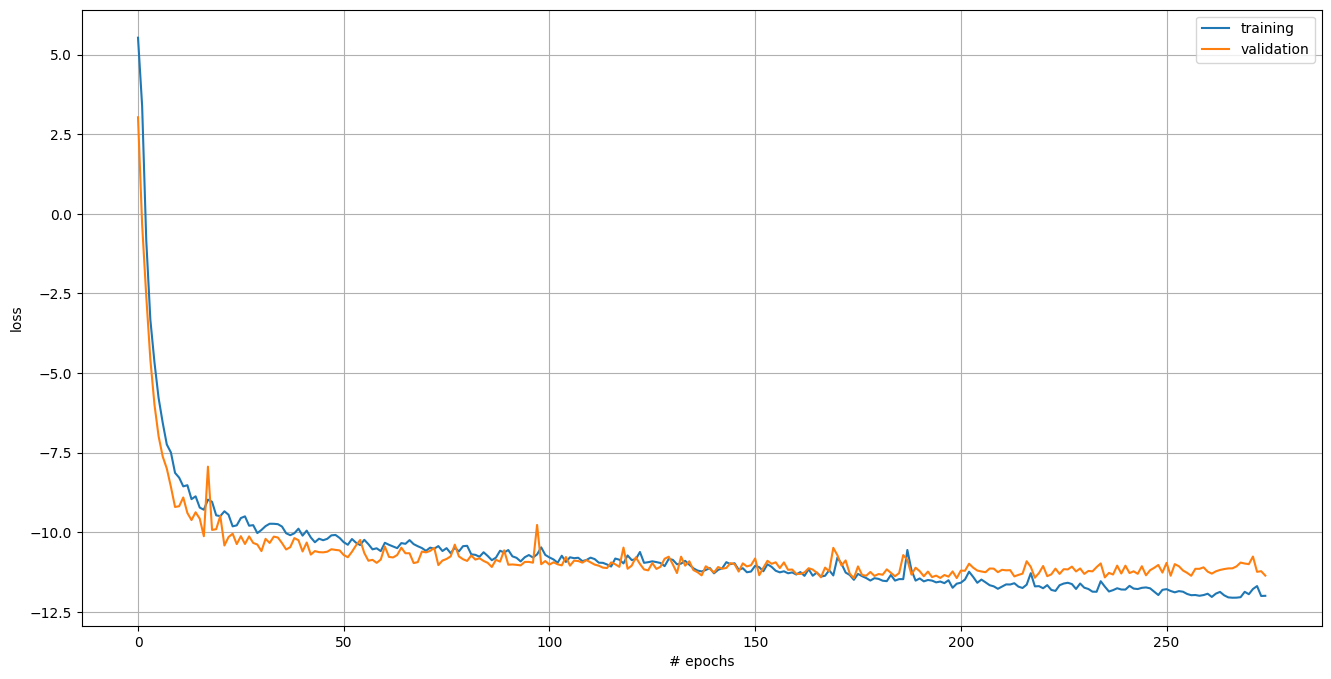

In [20]:
# p(y | x) <=> p(cls | theta)
model = ConditionalGMM(
    # theta
    x_dim=x_gauss_mix.shape[1],
    # cls
    y_dim=y_gauss_mix.shape[1],
    out_dir=None,
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

# training
fit_history = model.fit(
    x=x_gauss_mix,
    y=y_gauss_mix,
    epochs=500,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=False,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## MCMC and plot

In [21]:
temp_grid_obs = tf.expand_dims(grid_compressed_cls[100], axis=0)
temp_fidu_obs = tf.cast(obs_compressed_cls, dtype=tf.float32)

print(temp_grid_obs)
print(temp_fidu_obs, "\n")

print(model.log_likelihood(grid_theta, temp_grid_obs))
print(model.log_likelihood(grid_theta, temp_fidu_obs), "\n")

print(np.count_nonzero(~np.isnan(model.log_likelihood(grid_theta, temp_grid_obs))))
print(np.count_nonzero(~np.isnan(model.log_likelihood(grid_theta, temp_fidu_obs))))

tf.Tensor(
[[ 1.3884262   0.06495861 -0.5279618  -0.5423786  -0.6970048   1.2223688
   0.5677663   0.19913477  0.3021322  -0.9693126 ]], shape=(1, 10), dtype=float32)
tf.Tensor(
[[-2.5190618 -7.5883036 -1.7090161  5.5450063 -7.7385964  6.7494016
   8.539173  14.488028   3.1312325  2.6265752]], shape=(1, 10), dtype=float32) 

[-16.114653 -16.114653 -16.114653 ... -16.24757  -16.24757  -16.24757 ]
[nan nan nan ... nan nan nan] 

39984
0


In [ ]:
tf_pred = tf.cast(obs_compressed_cls, dtype=tf.float64)
# tf_pred = tf.cast(obs_cls[np.newaxis,:], dtype=tf.float32)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)
    

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=None,
    label=label,
    n_steps=500,
)

plotting.plot_chain(
    chain, 
    params, 
    out_dir=None, 
    label=label,
)

# inference with Gaussian likelihood

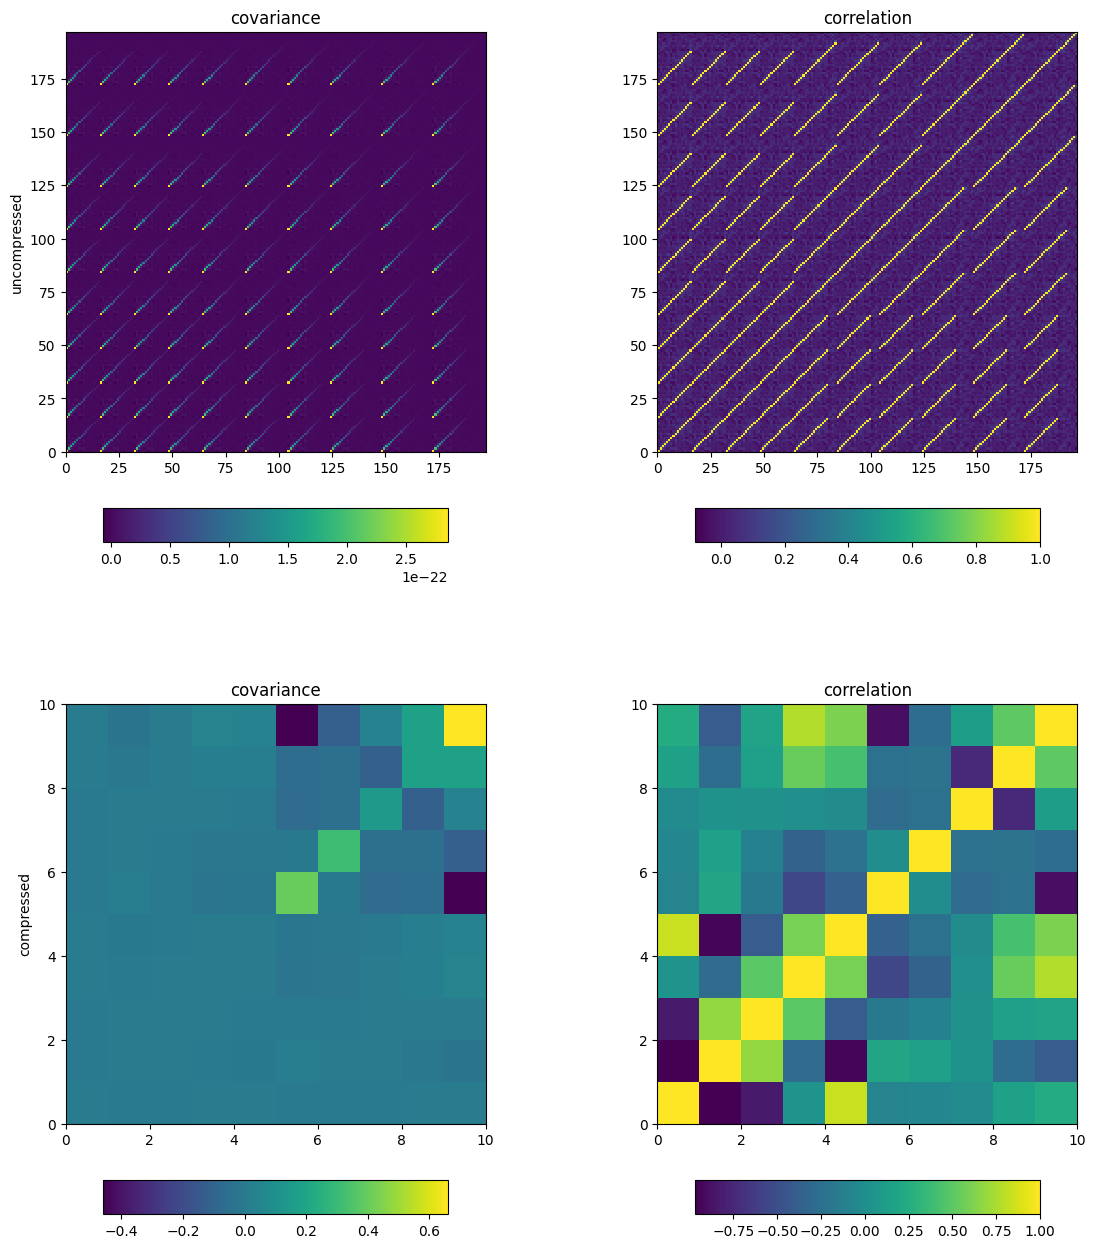

In [36]:
fidu_cov = np.cov(fidu_cls, rowvar=False)
fidu_corr = np.corrcoef(fidu_cls, rowvar=False)

# standardized
fidu_standard_cov = np.cov(fidu_standard_cls, rowvar=False)
fidu_standard_corr = np.corrcoef(fidu_standard_cls, rowvar=False)

# compressed
fidu_compressed_cov = np.cov(fidu_compressed_cls, rowvar=False)
fidu_compressed_corr = np.corrcoef(fidu_compressed_cls, rowvar=False)

# plot
fig, ax = plt.subplots(figsize=(14,16), ncols=2, nrows=2)

# uncompressed

# covariance
im = ax[0,0].pcolormesh(fidu_cov)
ax[0,0].set(title="covariance", ylabel="uncompressed")
ax[0,0].set_aspect("equal")

fig.colorbar(im, ax=ax[0,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[0,1].pcolormesh(fidu_corr)
ax[0,1].set(title="correlation")
ax[0,1].set_aspect("equal")

fig.colorbar(im, ax=ax[0,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# compressed

# covariance
im = ax[1,0].pcolormesh(fidu_compressed_cov)
ax[1,0].set(title="covariance", ylabel="compressed")
ax[1,0].set_aspect("equal")

fig.colorbar(im, ax=ax[1,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1,1].pcolormesh(fidu_compressed_corr)
ax[1,1].set(title="correlation")
ax[1,1].set_aspect("equal")

fig.colorbar(im, ax=ax[1,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

In [11]:
x_gauss_like = grid_theta

y_gauss_like = grid_standard_cls
cov_gauss_like = fidu_standard_cov
obs_gauss_like = obs_standard_cls

# y_gauss_like = grid_compressed_cls
# cov_gauss_like = fidu_compressed_cov
# obs_gauss_like = obs_compressed_cls

23-07-06 06:48:23 dense_emulat INF   Preprocessing scalers have been successfully fit 
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3)]               0         
                                                                 
 tf.math.subtract (TFOpLambd  (None, 3)                0         
 a)                                                              
                                                                 
 tf.math.truediv (TFOpLambda  (None, 3)                0         
 )                                                               
                                                                 
 dense (Dense)               (None, 1024)              4096      
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                        

epoch:  46%|████▌     | 462/1000 [00:52<01:01,  8.77it/s, loss=0.211, val_loss=0.163, lr=None]

Restoring model weights from the end of the best epoch: 363.


epoch:  46%|████▋     | 463/1000 [00:52<01:08,  7.85it/s, loss=0.212, val_loss=0.162, lr=None]

Epoch 463: early stopping


epoch:  46%|████▋     | 463/1000 [00:52<01:01,  8.76it/s, loss=0.212, val_loss=0.162, lr=None]


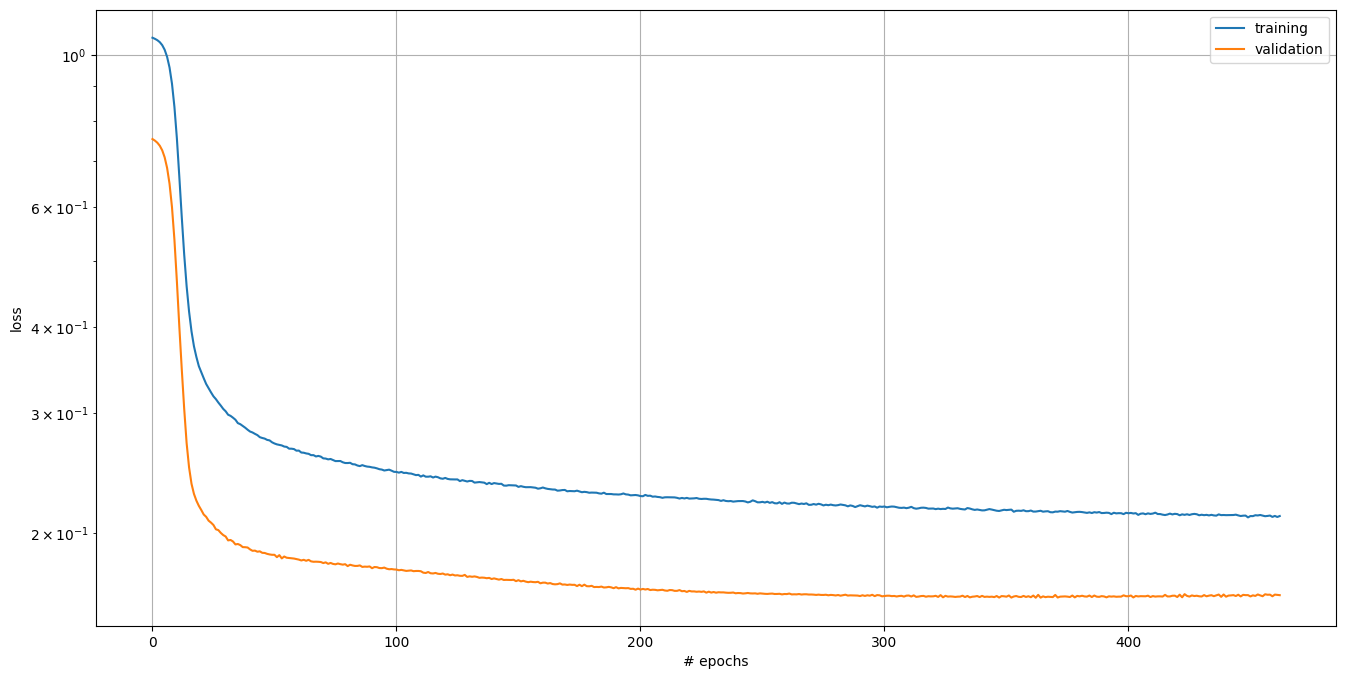

In [12]:
# f(x) = y
emu = DenseEmulator(
    x=x_gauss_like, 
    y=y_gauss_like,
    n_units=1024, 
    n_layers=5, 
    dropout_rate=0.2,
    learning_rate=1e-5,
)

# training
history = emu.fit(
    x=x_gauss_like, 
    y=y_gauss_like,
    validation_split=0.2, 
    batch_size=2499,
    epochs=1000,
    early_stopping_callback=True,
    # learning_rate_callback=False,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

## MCMC and plot

In [13]:
tf_cholesky = tf.linalg.cholesky(tf.cast(cov_gauss_like, dtype=tf.float32))
tf_pred = tf.cast(obs_gauss_like, dtype=tf.float32)

def log_likelihood(X): 
    # X = emu.scale_forward_x(X)
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=None,
    label=label,
)

plotting.plot_chain(
    chain, 
    params, 
    out_dir=None, 
    label=label,
)

23-07-06 06:49:37      mcmc.py INF   Initial values in prior: True 


2023-07-06 06:49:37.949346: W tensorflow/core/kernels/linalg/cholesky_op_gpu.cu.cc:211] Cholesky decomposition was not successful for batch 0. The input might not be valid. Filling lower-triangular output with NaNs.


ValueError: Probability function returned NaN